# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Shravya Etta

**Date:** 09/09/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.

**QUESTION 1**

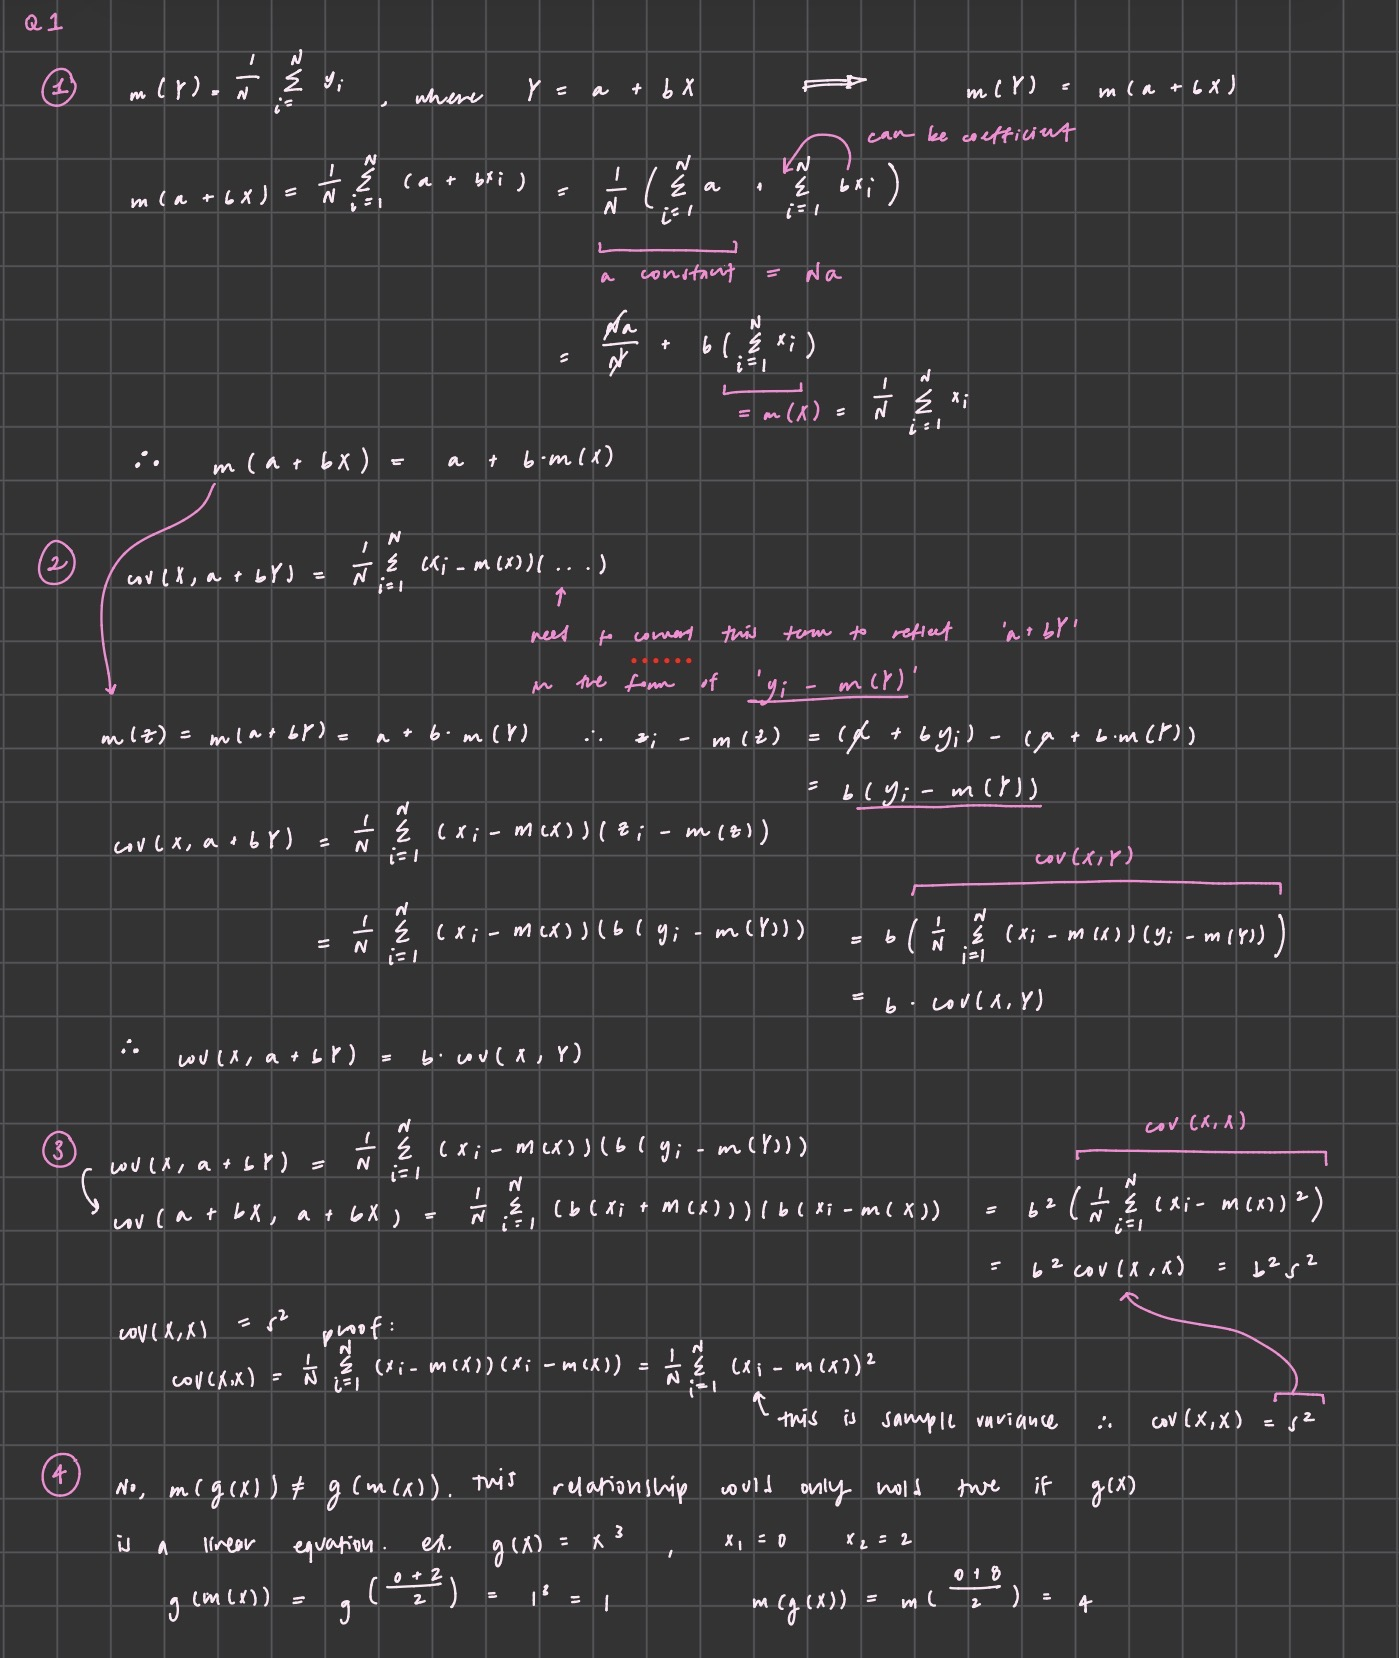

**QUESTION 2**



In [5]:
import pandas as pd

df_gift = pd.read_csv("ForeignGifts_edu.csv")
df_gift.head(10)

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
5,6,105100,University of Alabama,Tuscaloosa,AL,43501,30231,Contract,KUWAIT,Kuwait-Embassy of the State
6,7,105100,University of Alabama,Tuscaloosa,AL,43507,30162,Contract,KUWAIT,Kuwait-Embassy of the State
7,8,105100,University of Alabama,Tuscaloosa,AL,43517,200,Monetary Gift,GERMANY,"Mercedes-Benz U.S. International, I"
8,9,105100,University of Alabama,Tuscaloosa,AL,43529,5136,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
9,10,105100,University of Alabama,Tuscaloosa,AL,43531,57049,Contract,JAPAN,Kansai Gaidai University (KGU)


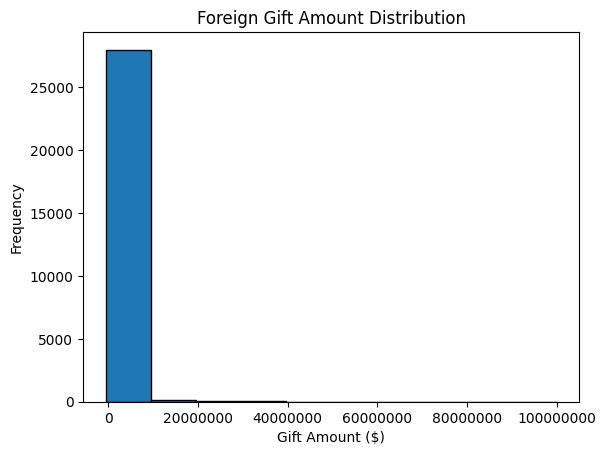

In [42]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.hist(df_gift["Foreign Gift Amount"], edgecolor="black")
plt.title("Foreign Gift Amount Distribution")
plt.xlabel("Gift Amount ($)")
plt.ylabel("Frequency")
plt.ticklabel_format(style="plain", axis="x") # don't want to scale down x-axis values
plt.show()

The histogram above depicts that a large proportion of the gifts are valued in the 'lower' range of 0-10 million. There are a lower proportion gifts valued around 20 million dollars and above, and at least one gift valued in the 100 million dollar range. This histogram indicates that, even though the graph is heavily skewed to the right, foreign gifts as a whole have immense financial value.

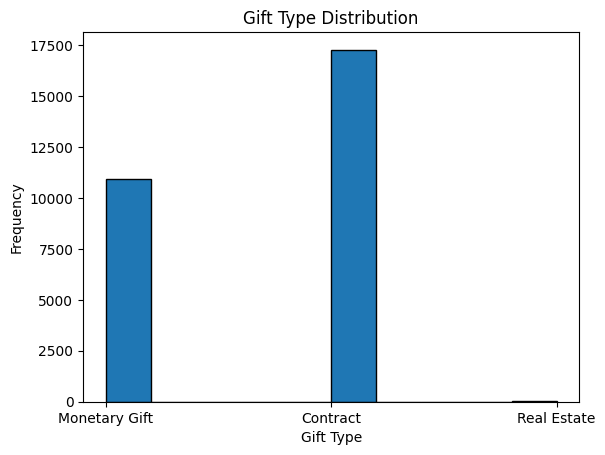

In [7]:
plt.figure()
plt.hist(df_gift["Gift Type"], edgecolor="black")
plt.title("Gift Type Distribution")
plt.xlabel("Gift Type")
plt.ylabel("Frequency")
plt.show()

Contracts and monetary gifts combined account for over 95% of all reported gifts in the dataset. Specifically, contract-type gifts represent ~1.5 times that of monetary-type gifts.

Real estate gifts account for a very small proportion of the dataset, which could be expected since these types of transactions are likely more complicated to file across countries.

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


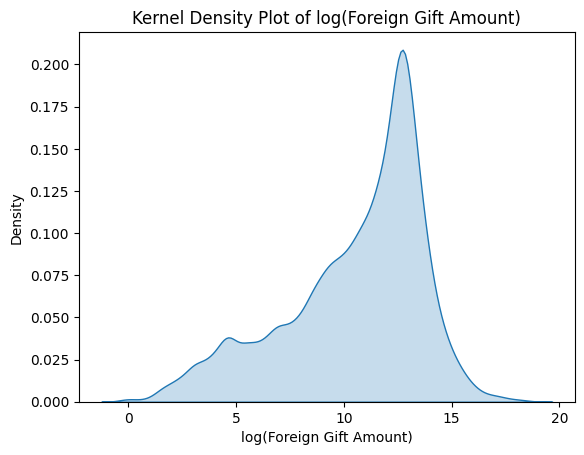

In [14]:
import seaborn as sns

# first density plot
df_gift["log_amount"] = np.log(df_gift["Foreign Gift Amount"])

plt.figure()
sns.kdeplot(df_gift["log_amount"], fill=True)
plt.title("Kernel Density Plot of log(Foreign Gift Amount)")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

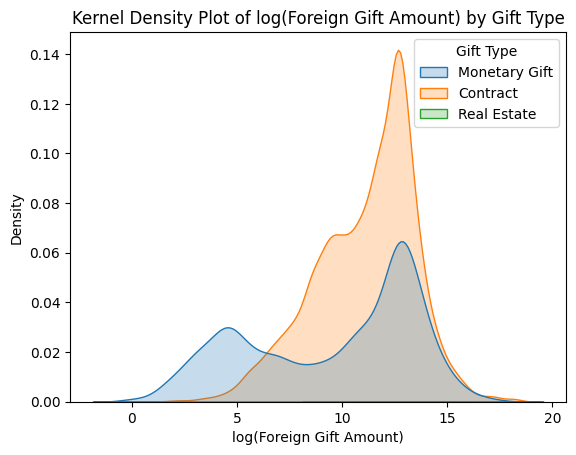

In [22]:
# second density plot; dependent on gift size
plt.figure()
sns.kdeplot(
    data=df_gift,
    x="log_amount",
    hue="Gift Type",
    fill=True
)
plt.title("Kernel Density Plot of log(Foreign Gift Amount) by Gift Type")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

Both the density plots above have a bell-shaped, normal distribution, indicating that log-transforming the variables helped more clearly display their characteristics.

The second plot further bolsters that real-estate gifts have an insignificant contribution to foreign gifts, considering that there were not enough real-estate-type gifts to even be shown on the figure. Within monetary and contract gifts, there is a greater distribution of monteary gifts across lower gift sizes. Contract gifts on the other hand, are more centrally distributed, which could reflect the result of long-term, high value contracts. Additionally, there is a spike in both of the plotted gift types around 12-13 millions of dollars.

In [35]:
top = (
    df_gift.groupby("Country of Giftor")["Foreign Gift Amount"]
    .count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="Number of Gifts") # reformatting + country name
)

top_sum = (
    df_gift.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="Total Amount (USD)") # reformatting + country name
)

print(f"Top 15 Countries by # of Gifts\n\n", top.to_string(index=False))
print(f"\n\nTop 15 Countries by Amount Gifted (USD)\n\n", top_sum.to_string(index=False))

Top 15 Countries by # of Gifts

 Country of Giftor  Number of Gifts
          ENGLAND             3655
            CHINA             2461
           CANADA             2344
            JAPAN             1896
      SWITZERLAND             1676
     SAUDI ARABIA             1610
           FRANCE             1437
          GERMANY             1394
        HONG KONG             1080
      SOUTH KOREA              811
            QATAR              693
  THE NETHERLANDS              512
            KOREA              452
            INDIA              434
           TAIWAN              381


Top 15 Countries by Amount Gifted (USD)

    Country of Giftor  Total Amount (USD)
               QATAR          2706240869
             ENGLAND          1464906771
               CHINA          1237952112
        SAUDI ARABIA          1065205930
             BERMUDA           899593972
              CANADA           898160656
           HONG KONG           887402529
               JAPAN           6559

The top 15 countries in terms of gift quantity and gift value (USD) are both shown above.

In [37]:
top_giftors = (
    df_gift.groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="Total Amount (USD)")
)

print(f"Top 15 Foreign Giftors by Total Amount\n\n", top_giftors.to_string(index=False))

Top 15 Foreign Giftors by Total Amount

                         Giftor Name  Total Amount (USD)
                   Qatar Foundation          1166503744
Qatar Foundation/Qatar National Res           796197000
     Qatar Foundation for Education           373945215
                          Anonymous           338793629
     Saudi Arabian Cultural Mission           275221475
                                HCL           190000000
      Church of Jesus Christ of LDS           185203715
 Emirates Institute for Advanced Sc           170641244
                                QIC           148355497
                       Anonymous #9            96334996
       Qatar National Research Fund            79021705
         Government of Saudi Arabia            75192434
                  Contracting Party            69996984
                    CMKL University            67700000
      Royal Embassy of Saudi Arabia            67062486


All three of the top giftors in terms of gift value (USD) are Qatar-based organizations.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 7317a046b8efdc73f1cd87976a7371093a1c6fd0

**Note: I forgot to commit my work for phase 1 after uploading the image of my Q1 response, but uploaded it afterwords and the original work is shown under Phase 1 in the Phase 2 commit.

- **AI tool and model used:** Gemini

### *Prompts used

1. Referencing the attached .ipynb notebook, suggest changes I can make to my solutions (in Phase 1) to the following questions:

Q1. In class, we talked about how to compute the sample mean of a variable  𝑋 ,
𝑚(𝑋)=1𝑁∑𝑖=1𝑁𝑥𝑖
and sample covariance of two variables  𝑋  and  𝑌 ,
cov(𝑋,𝑌)=1𝑁∑𝑖=1𝑁(𝑥𝑖−𝑚(𝑋))(𝑦𝑖−𝑚(𝑌))).
Recall, the sample variance of  𝑋  is
𝑠2=1𝑁∑𝑖=1𝑁(𝑥𝑖−𝑚(𝑋))2.
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

Show that  𝑚(𝑎+𝑏𝑋)=𝑎+𝑏×𝑚(𝑋) .
Show that  cov(𝑋,𝑎+𝑏𝑌)=𝑏×cov(𝑋,𝑌)
Show that  cov(𝑎+𝑏𝑋,𝑎+𝑏𝑋)=𝑏2cov(𝑋,𝑋) , and in particular that  cov(𝑋,𝑋)=𝑠2 .
Consider a non-decreasing transformation  𝑔() . Is is always true that  𝑚(𝑔(𝑋))=𝑔(𝑚(𝑋)) ?


Q2. This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, .groupby([vars]).count() and .groupby([vars]).sum() will be especially useful to tally the number of occurrences and sum the values of those occurrences.

Load the ./data/ForeignGifts_edu.csv dataset.
For Foreign Gift Amount, create a histogram and describe the variable. Describe your findings.
For Gift Type, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
Create a kernel density plot of the log of Foreign Gift Amount, and then a kernel density plot of the log of Foreign Gift Amount conditional on gift type. Do you notice any patterns?
What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
Which giftors provide the most money, in total?

2. Attached is the foreign gifts dataset. Suggest changes I should make to my code in the .ipynb file to fix any errors made, or make improvements in general.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

**Question 1:**

1. ($m(a + bX) = a + b \cdot m(X)$):Observation: Your proof expands $\frac{1}{N}\sum(a + bx_i)$ correctly.  Suggestion: Make sure to explicitly justify pulling out the constant term: state that $\sum_{i=1}^N a = N \cdot a$, so $\frac{1}{N}(Na) = a$.

2. ($\operatorname{cov}(X, a + bY) = b \cdot \operatorname{cov}(X, Y)$):Observation: You correctly identified that the mean of $a + bY$ is $a + b \cdot m(Y)$.  Suggestion: Add an explicit intermediate simplification step showing how the additive constant $a$ cancels out:$$(a + by_i) - (a + b \cdot m(Y)) = a - a + b(y_i - m(Y)) = b(y_i - m(Y))$$This makes it immediately clear why adding a constant shift has zero impact on covariance.

3. ($\operatorname{cov}(a + bX, a + bX) = b^2 \operatorname{cov}(X, X)$ and $\operatorname{cov}(X, X) = s^2$):Observation: The substitution into the sample variance definition is sound.  Suggestion: Explicitly mention that centering both terms produces $[b(x_i - m(X))] \cdot [b(x_i - m(X))] = b^2 (x_i - m(X))^2$, allowing $b^2$ to be factored completely out of the summation operator.

4. ($m(g(X)) = g(m(X))$ for non-decreasing $g$):Observation: Your answer states that this holds only for linear functions, but it lacks a concrete counterexample.  Suggestion: A non-decreasing function preserves order, not linearity (Jensen’s inequality). Strengthen your answer by providing a simple numerical counterexample:Let $g(x) = x^3$ (strictly increasing/non-decreasing for all $x \in \mathbb{R}$).Take $x_1 = 0$ and $x_2 = 2$.$m(X) = \frac{0 + 2}{2} = 1 \implies g(m(X)) = 1^3 = 1$.$m(g(X)) = \frac{0^3 + 2^3}{2} = \frac{0 + 8}{2} = 4$.Since $4 \neq 1$, $m(g(X)) \neq g(m(X))$.

**Question 2:**

5. Data Ingestion & Robustness: Fix Relative Path (Sub-question 1): Update pd.read_csv("ForeignGifts_edu.csv") to look in ./data/ForeignGifts_edu.csv as specified in the assignment prompt (or wrap with a try/except FileNotFoundError fallback).
Filter Non-Positive Values Before Log Transformation (Sub-question 4): Filter out the 24 negative/zero transaction amounts (e.g., -537770, -1) before taking np.log() to prevent NaN values and RuntimeWarning: invalid value encountered in log.

6. Visualization Improvements: Adjust Histogram Binning (Sub-question 2): Increase the bin count (e.g., bins=50) on the raw Foreign Gift Amount histogram so the distribution's concentration near the origin and the long right tail are clearly distinguishable. Convert Categorical Histogram to Frequency/Proportion Table (Sub-question 3): Replace or complement plt.hist(df_gift["Gift Type"]) with df_gift["Gift Type"].value_counts(normalize=True) to explicitly report the exact proportions requested (Contracts: 61.21%, Monetary Gifts: 38.75%, Real Estate: 0.04%). Set common_norm=False on Hue KDE (Sub-question 4): Add common_norm=False to sns.kdeplot(..., hue="Gift Type") so that the small sample size of Real Estate ($n=11$) is normalized to its own area rather than being flattened to zero density against the dominant Contract category ($n=17,250$).

 7. Statistical Analysis & Interpretation Fixes: Include Descriptive Summary Statistics (Sub-question 2): Add df_gift["Foreign Gift Amount"].describe() output in addition to the histogram to discuss the arithmetic mean ($\$588,233$) versus the median ($\$94,615$), emphasizing the heavy right tail where over $90\%$ of gifts are under $\$1\text{M}$. Correct Log Scale Interpretation (Sub-question 4): Correct the observation in Cell 17 stating that the spike occurs around "12–13 millions of dollars". Clarify that on the natural log scale, $e^{12.43} \approx \$250,000$, which corresponds to the federal disclosure threshold under Section 117 of the Higher Education Act of 1965 ($\$10\text{M}$ would be $\ln(10^7) \approx 16.1$).  

 8. Output Formatting & Aggregations[ ] Apply Currency Formatting (Sub-questions 5 & 6): Format large aggregate numbers in top_sum and top_giftors with dollar signs and commas (e.g., "${:,.2f}".format or apply(lambda x: f"${x:,.2f}")) instead of raw scientific notation/long integers. Account for Missing Names in Giftor Aggregation (Sub-question 6): Acknowledge or inspect the 3,751 missing values (NaN) in Giftor Name to confirm that unspecified/anonymous donors do not obscure individual top contributors.  

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept| I clarified my final solution but made no other changes. |
| 2 | Accept| I clarified my final solution but made no other changes. |
| 3 | Reject | I found this to be unecessary. |
| 4 | Reject | Gemini misread my solution as I had already provided a counter-example. |
| 5 | Modify| There was no issue with the relative path, but it was helpful to filter out the negative/zero values that could have skewed the data and figures. |
| 6 | Reject | In general, the aesthetic changes for the histogram did not make a major or beneficial difference. I think that normalizing the real estate variable area results in a misrepresentation of the data in this context. |
| 7 | Accept| Adding summary stats would be helpful in more accuractly discussing the data, since I previously made an approximate of "95%" in my initial discussion. |
| 8 | Accept | There was a minor change that improved formatting. Removing the missing values was helpful since there was a large proportion of aggregated anonymous donors reported previously.  |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.

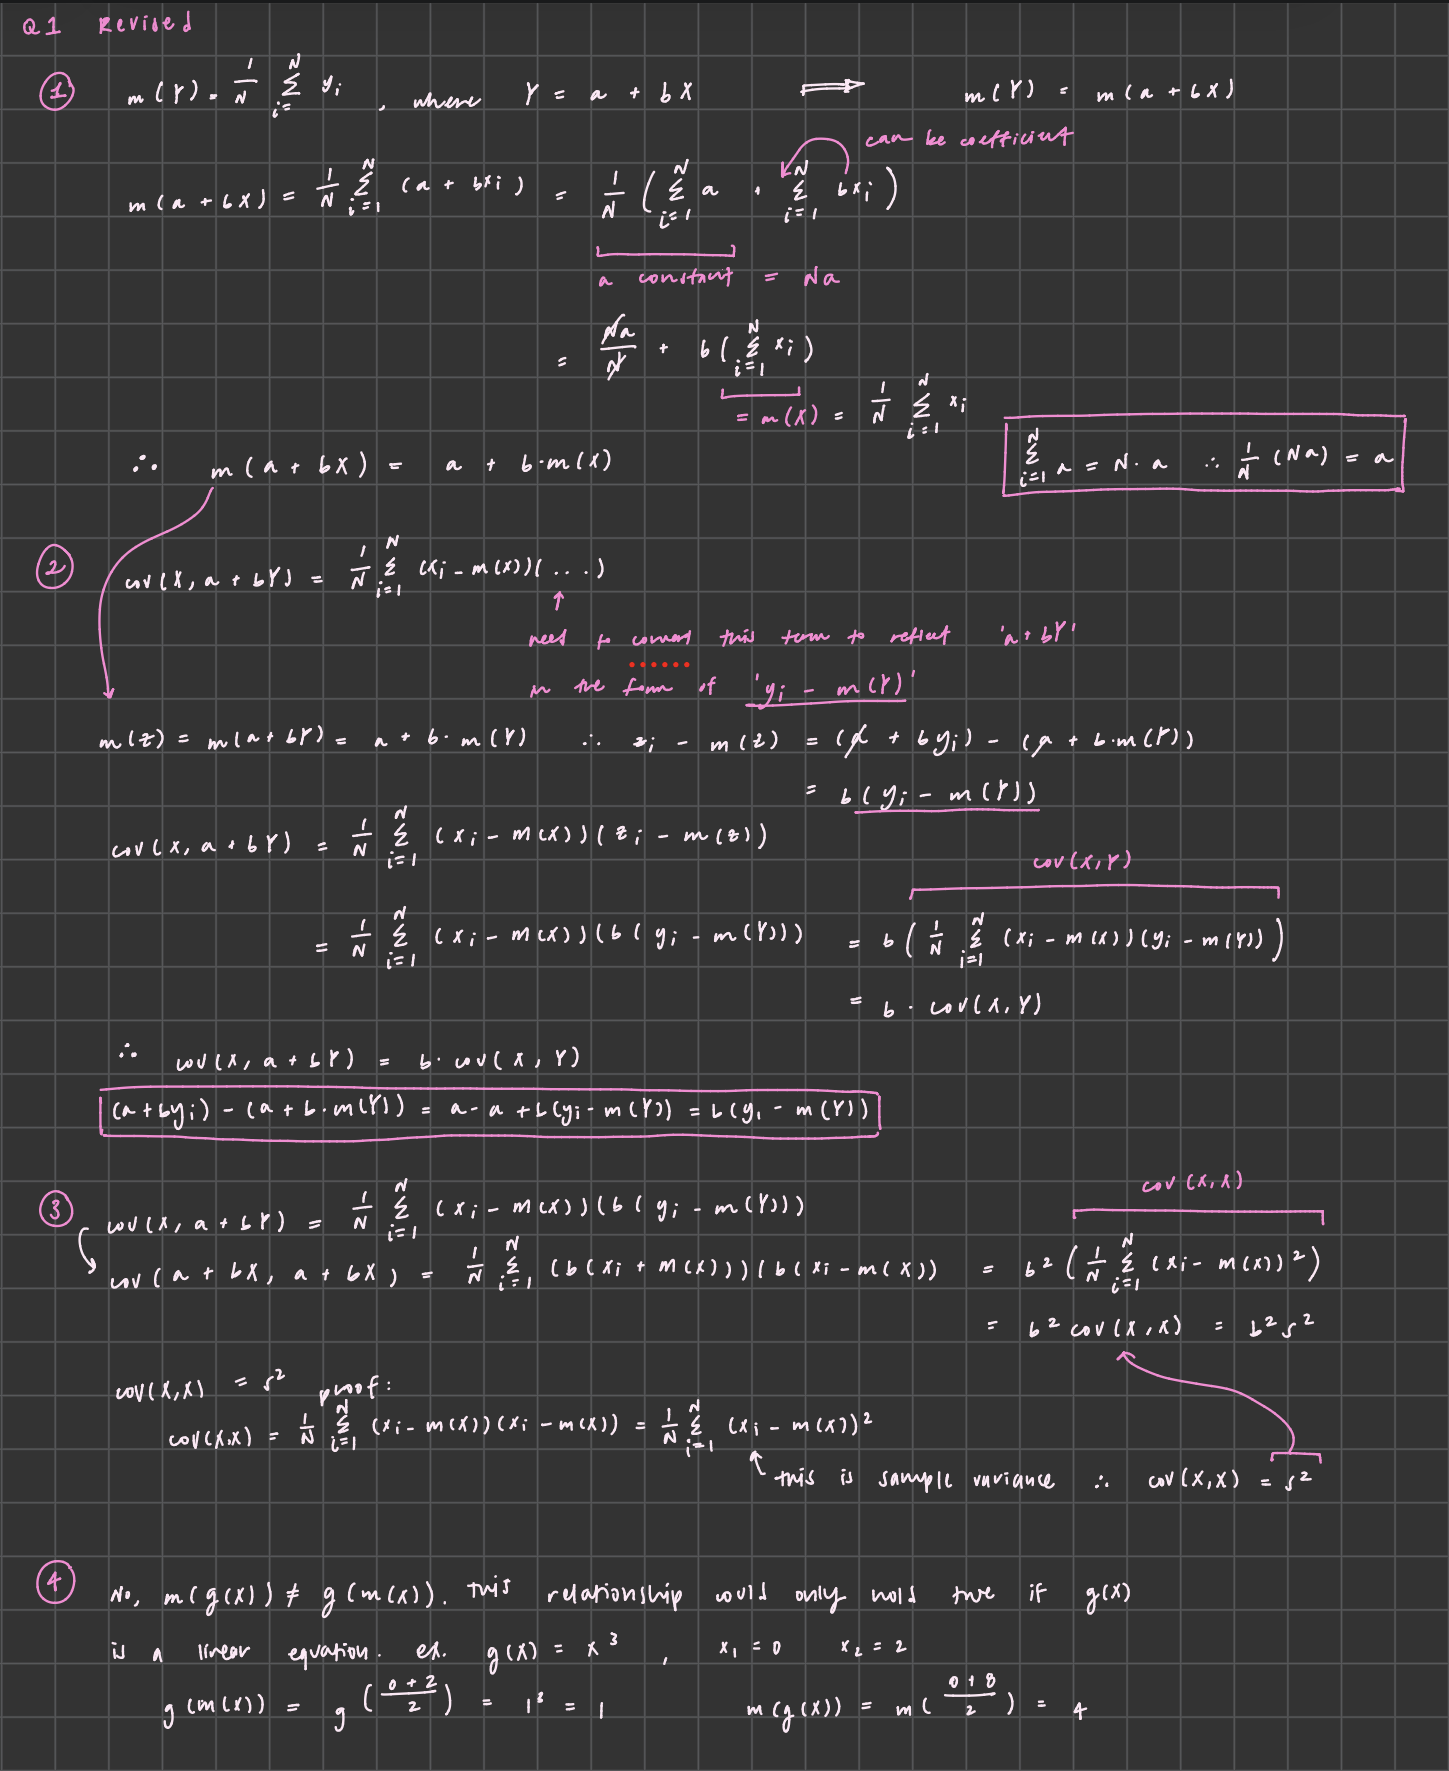

In [ ]:
import pandas as pd

df_gift = pd.read_csv("ForeignGifts_edu.csv")
df_gift.head(10)

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
5,6,105100,University of Alabama,Tuscaloosa,AL,43501,30231,Contract,KUWAIT,Kuwait-Embassy of the State
6,7,105100,University of Alabama,Tuscaloosa,AL,43507,30162,Contract,KUWAIT,Kuwait-Embassy of the State
7,8,105100,University of Alabama,Tuscaloosa,AL,43517,200,Monetary Gift,GERMANY,"Mercedes-Benz U.S. International, I"
8,9,105100,University of Alabama,Tuscaloosa,AL,43529,5136,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
9,10,105100,University of Alabama,Tuscaloosa,AL,43531,57049,Contract,JAPAN,Kansai Gaidai University (KGU)


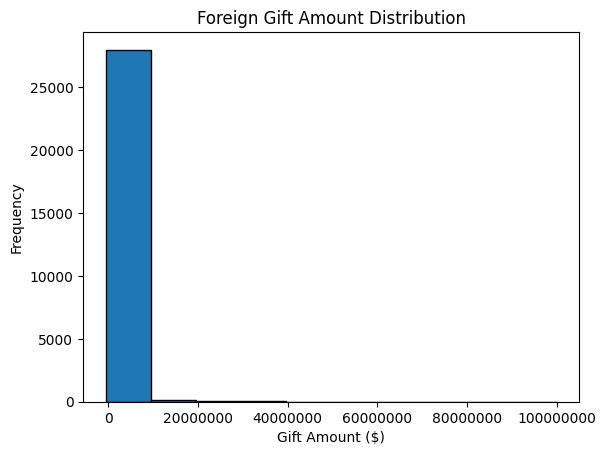

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.hist(df_gift["Foreign Gift Amount"], edgecolor="black")
plt.title("Foreign Gift Amount Distribution")
plt.xlabel("Gift Amount ($)")
plt.ylabel("Frequency")
plt.ticklabel_format(style="plain", axis="x") # don't want to scale down x-axis values
plt.show()


--- Gift Type Breakdown ---
               Count  Proportion Percent
Gift Type                               
Contract       17274    0.612097  61.21%
Monetary Gift  10936    0.387513  38.75%
Real Estate       11    0.000390   0.04%


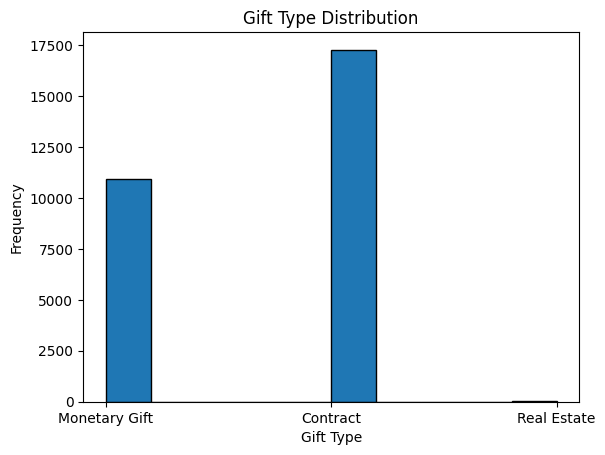

In [53]:
gift_counts = df_gift["Gift Type"].value_counts(dropna=False)
gift_props = df_gift["Gift Type"].value_counts(normalize=True, dropna=False)
gift_summary = pd.DataFrame({
    "Count": gift_counts,
    "Proportion": gift_props,
    "Percent": (gift_props * 100).round(2).astype(str) + "%"
})
print("\n--- Gift Type Breakdown ---")
print(gift_summary)

plt.figure()
plt.hist(df_gift["Gift Type"].dropna(), edgecolor="black")
plt.title("Gift Type Distribution")
plt.xlabel("Gift Type")
plt.ylabel("Frequency")
plt.show()

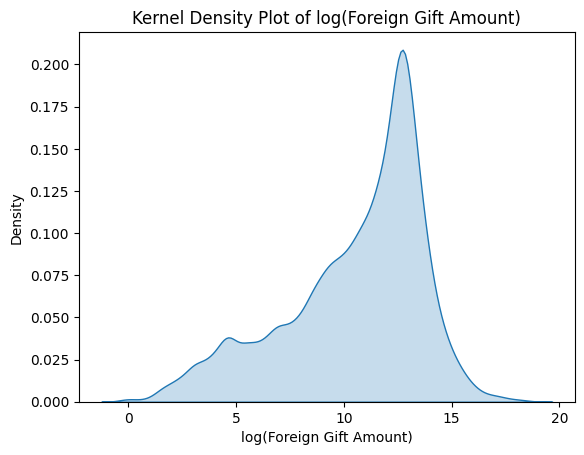

In [55]:
import seaborn as sns

# first density plot
df_positive = df_gift[df_gift["Foreign Gift Amount"] > 0].copy()
df_positive["log_amount"] = np.log(df_positive["Foreign Gift Amount"])

plt.figure()
sns.kdeplot(df_positive["log_amount"], fill=True)
plt.title("Kernel Density Plot of log(Foreign Gift Amount)")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

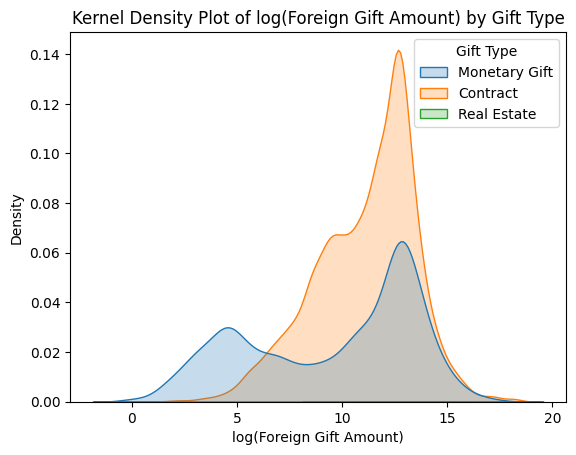

In [56]:
# second density plot; dependent on gift size
plt.figure()
sns.kdeplot(
    data=df_positive,
    x="log_amount",
    hue="Gift Type",
    fill=True
)
plt.title("Kernel Density Plot of log(Foreign Gift Amount) by Gift Type")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

In [60]:
top = (
    df_gift.groupby("Country of Giftor")["Foreign Gift Amount"]
    .count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="Number of Gifts") # reformatting + country name
)

top_sum = (
    df_gift.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="Total Amount (USD)") # reformatting + country name
)

print(f"Top 15 Countries by # of Gifts\n\n", top.to_string(index=False))
print(f"\n\nTop 15 Countries by Amount Gifted (USD)\n\n", top_sum.to_string(index=False, formatters={"Total Amount (USD)": "${:,.2f}".format}))

Top 15 Countries by # of Gifts

 Country of Giftor  Number of Gifts
          ENGLAND             3655
            CHINA             2461
           CANADA             2344
            JAPAN             1896
      SWITZERLAND             1676
     SAUDI ARABIA             1610
           FRANCE             1437
          GERMANY             1394
        HONG KONG             1080
      SOUTH KOREA              811
            QATAR              693
  THE NETHERLANDS              512
            KOREA              452
            INDIA              434
           TAIWAN              381


Top 15 Countries by Amount Gifted (USD)

    Country of Giftor Total Amount (USD)
               QATAR  $2,706,240,869.00
             ENGLAND  $1,464,906,771.00
               CHINA  $1,237,952,112.00
        SAUDI ARABIA  $1,065,205,930.00
             BERMUDA    $899,593,972.00
              CANADA    $898,160,656.00
           HONG KONG    $887,402,529.00
               JAPAN    $655,954,776.00
   

In [59]:
top_giftors = (
    df_gift.groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="Total Amount (USD)")
)

print(f"Top 15 Foreign Giftors by Total Amount\n\n", top_giftors.to_string(index=False, formatters={"Total Amount (USD)": "${:,.2f}".format}))

Top 15 Foreign Giftors by Total Amount

                         Giftor Name Total Amount (USD)
                   Qatar Foundation  $1,166,503,744.00
Qatar Foundation/Qatar National Res    $796,197,000.00
     Qatar Foundation for Education    $373,945,215.00
                          Anonymous    $338,793,629.00
     Saudi Arabian Cultural Mission    $275,221,475.00
                                HCL    $190,000,000.00
      Church of Jesus Christ of LDS    $185,203,715.00
 Emirates Institute for Advanced Sc    $170,641,244.00
                                QIC    $148,355,497.00
                       Anonymous #9     $96,334,996.00
       Qatar National Research Fund     $79,021,705.00
         Government of Saudi Arabia     $75,192,434.00
                  Contracting Party     $69,996,984.00
                    CMKL University     $67,700,000.00
      Royal Embassy of Saudi Arabia     $67,062,486.00


### *Reflection on AI assistance
In your own words without generative AI.

The main improvements AI helped me with for this assignment were improving my responses via the addition of summary statistics, formatting changes, and better cleaning the data based on the type of figure I was making. It also suggested a different way to plot the density figure data. While I felt that it's approach did not fit the context of this assignment, it was nice to consider another approach and learn what that code could help with in the future.

However, AI made a few mistakes with analyzing the work I had already done, as it provided repetetive advice. Additionally, I felt that the long length of the AI response slowed down my work. In the future, I plan to be more concise with my AI prompts so that it does not offer any uneccesary information.